# Modélisation et prévision des trajets en Vélib'

#### Nour Bouabid et Marya Khelifa

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
from sklearn.metrics import mean_absolute_error, mean_squared_error



---
# Aperçu de Yt

In [102]:
#import des données

data=pd.read_csv("velib_horaire.csv")
data["Departure_Time"]= pd.to_datetime(data["Departure_Time"])
data = data.sort_values("Departure_Time").set_index("Departure_Time")

print(data.head())


                     duree_moyenne_sec  proportion_velos_electriques  \
Departure_Time                                                         
2024-05-01 00:00:00        1066.162766                      0.588298   
2024-05-01 01:00:00        1190.689723                      0.570299   
2024-05-01 02:00:00        1186.409469                      0.543506   
2024-05-01 03:00:00        1172.889674                      0.562500   
2024-05-01 04:00:00        1112.989264                      0.565184   

                     nombre_trajets  
Departure_Time                       
2024-05-01 00:00:00            4700  
2024-05-01 01:00:00            3542  
2024-05-01 02:00:00            3126  
2024-05-01 03:00:00            1840  
2024-05-01 04:00:00            1304  


In [ ]:
# extration du processus stationnaire à étudier
Y=data["nombre_trajets"].dropna()

#statistiques descriptives
print("Moyenne :", Y.mean())
print("Variance :", Y.var())
print("Écart-type :", Y.std())

Moyenne : 6016.092361111111
Variance : 17630569.02898957
Écart-type : 4198.877115252311


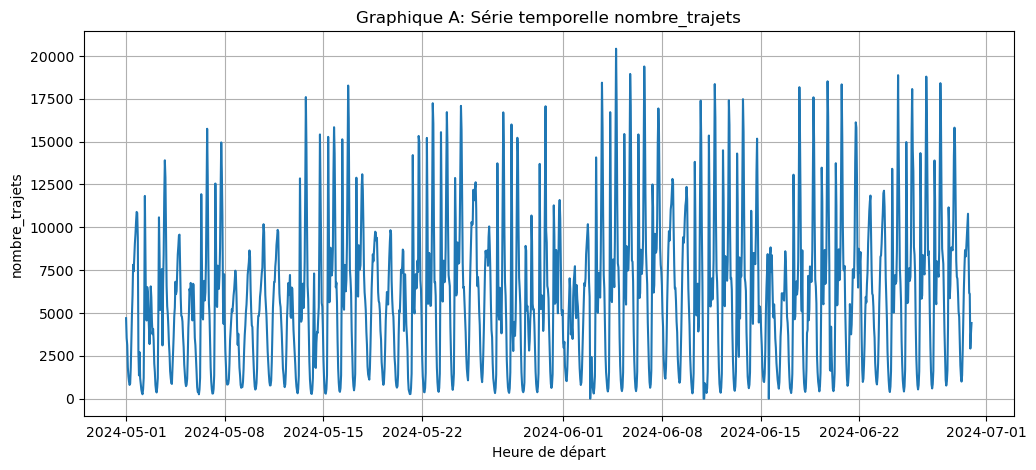

In [ ]:
#Courbe de Yt

plt.figure(figsize=(12, 5))
plt.plot(Y)
plt.title(f"Graphique A: Série temporelle {Y.name}")
plt.xlabel("Heure de départ")
plt.ylabel(f"{Y.name}")
plt.grid(True)
plt.show()

---

# Recherche d'une tendance polynomiale

In [ ]:
# test d'une tendance polynomiale de degré 3 avec une regression

t = np.arange(len(Y))
X = sm.add_constant(np.column_stack([t, t**2,t**3]))
mod = sm.OLS(Y.values, X).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     11.26
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           2.63e-07
Time:                        14:19:15   Log-Likelihood:                -14039.
No. Observations:                1440   AIC:                         2.809e+04
Df Residuals:                    1436   BIC:                         2.811e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4264.4720    436.801      9.763      0.0

- les coefficients des termes de degrès 2 et 3 sont supérieurs à 0,005 donc non significatifs.
- la tendance linéaire est significative car $t$ a une p-value de 0.023, mais R-squared=0.023, donc elle explique seulement 2.3 % de la variabilité. 

In [106]:
# retrait de la tendance polynomiamle de degrès 1

#par différentiation
y_sans_tendance = Y.diff(1).dropna()

#par estimation puis soustraction
'''
X = sm.add_constant(t)
mod_lin = sm.OLS(Y.values, X).fit()
y_sans_tendance = Y - mod_lin.fittedvalues'''

'\nX = sm.add_constant(t)\nmod_lin = sm.OLS(Y.values, X).fit()\ny_sans_tendance = Y - mod_lin.fittedvalues'

In [ ]:
# test d'une tendance polynomiale de degré 3 sur la série modifiée
t = np.arange(len(y_sans_tendance))
X = sm.add_constant(np.column_stack([t, t**2,t**3]))
mod = sm.OLS(y_sans_tendance.values, X).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                  0.003342
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               1.00
Time:                        14:19:15   Log-Likelihood:                -13293.
No. Observations:                1439   AIC:                         2.659e+04
Df Residuals:                    1435   BIC:                         2.662e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.6227    261.927      0.033      0.9

Plus aucun coefficient n'est significatif donc plus de tendance polynomiale

---

# Recherche de saisonnalité

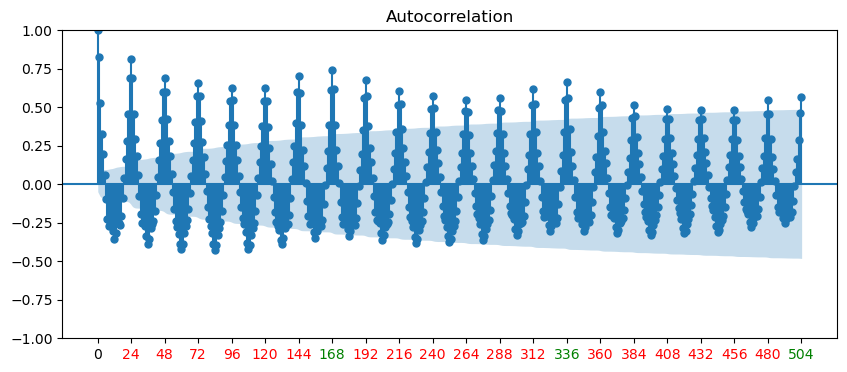

In [ ]:

#Affichage de l'ACF

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(Y, lags=24*21, ax=ax) #fonction d'autocorrélation de Y

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")

plt.show()

Les pics réguliers indiquent une saisonnalité journalière (indices rouges) et hebdomadaire (indices verts) .

In [109]:
# retrait de la saisonnalité

Y_diff24 = y_sans_tendance.diff(24)
Y_diff168= Y_diff24.diff(168)
Y_model= Y_diff168.dropna()

---

# Etude plus détaillée de la saisonnalité

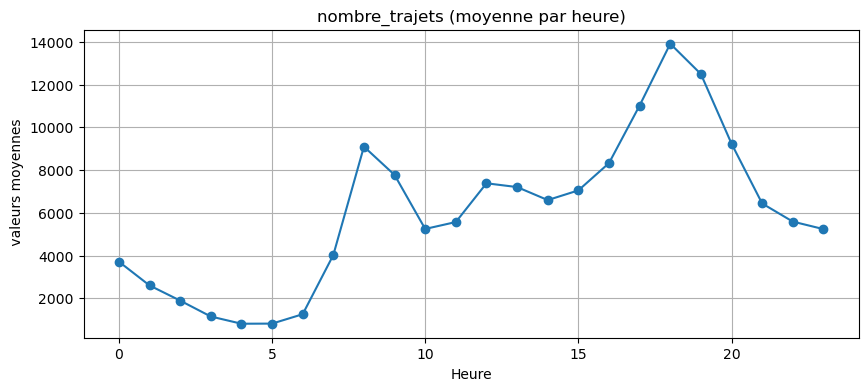

In [110]:
profil_horaire = Y.groupby(Y.index.hour).mean()

plt.figure(figsize=(10,4))
plt.plot(profil_horaire.index, profil_horaire.values, marker="o")
plt.title(f"{Y.name} (moyenne par heure)")
plt.xlabel("Heure")
plt.ylabel(" valeurs moyennes")
plt.grid(True)
plt.show()

On observe une dépendance à l'heure de la journée: heure de pointe matin et soir

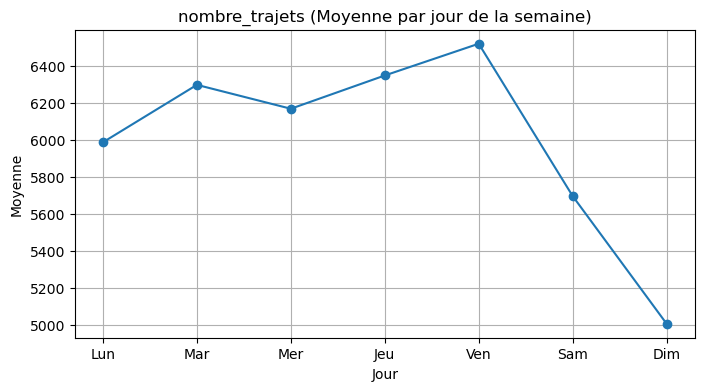

In [111]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
profil_semaine = Y.groupby(Y.index.dayofweek).mean()

plt.figure(figsize=(8,4))
plt.plot(jours, profil_semaine.values, marker="o")
plt.title(f"{Y.name} (Moyenne par jour de la semaine)")
plt.xlabel("Jour")
plt.ylabel("Moyenne")
plt.grid(True)
plt.show()

On observe une dépendance importante au jour de la semaine: baisse importante le weekend

---

# Pertinence du modèle ARMA

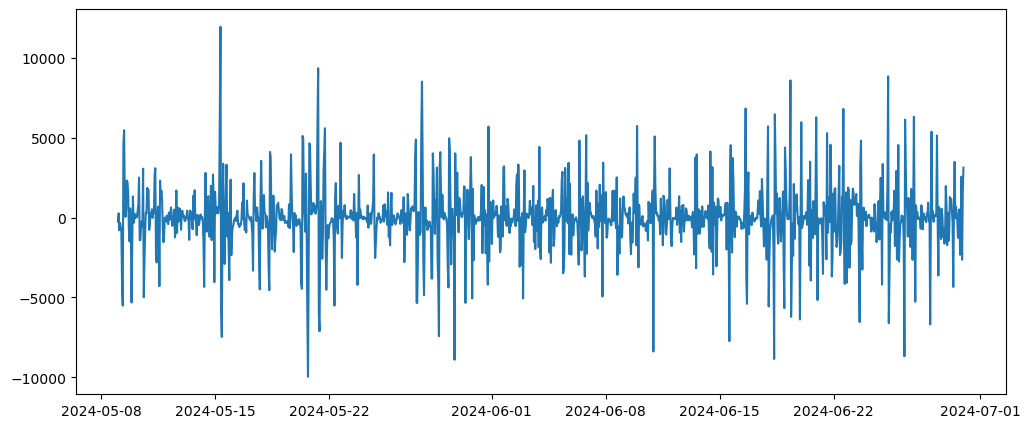

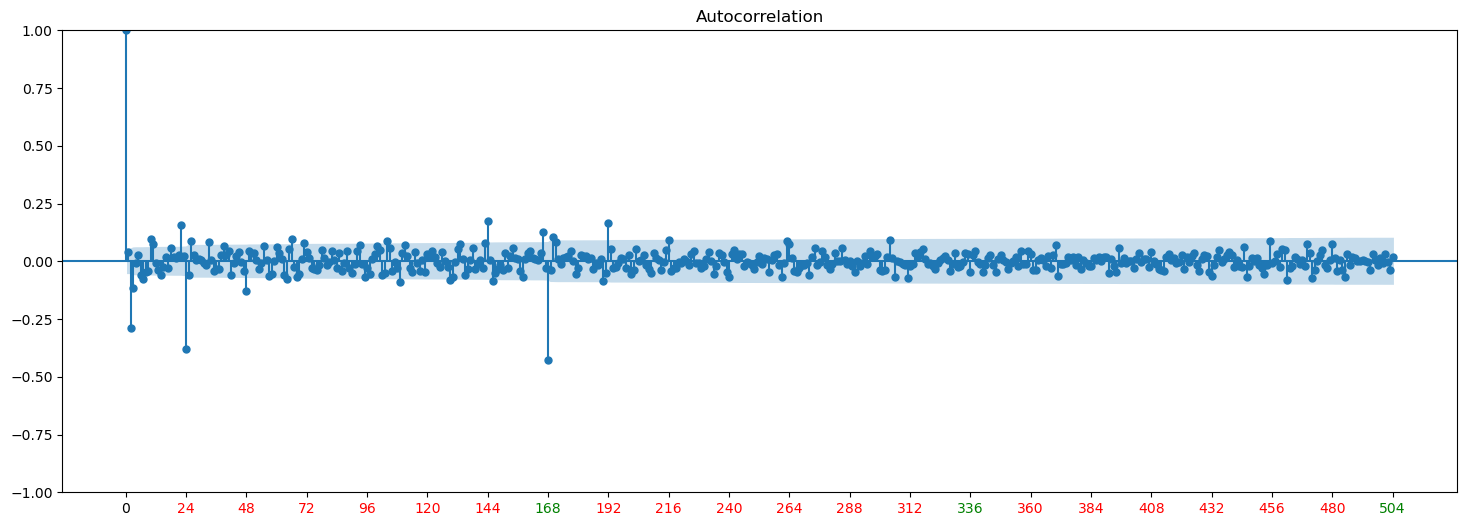

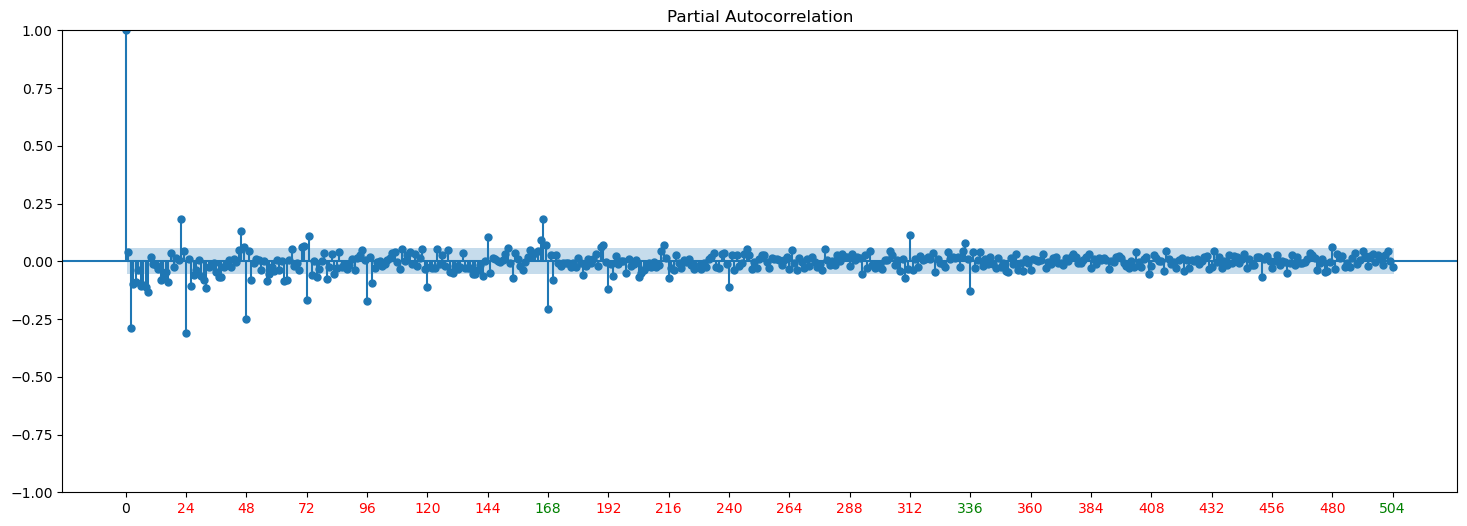

In [ ]:
#affichage de la série stationnarisée, ACF et PACF

plt.figure(figsize=(12, 5))
plt.plot(Y_model)

fig, ax = plt.subplots(figsize=(18, 6))
plot_acf(Y_model, lags=24*21,ax=ax)

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")

fig, ax = plt.subplots(figsize=(18, 6))
plot_pacf(Y_model, lags=24*21,ax=ax)

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")
plt.show()

— Analyse visuelle : pas de tendance, pas de saisonnalité,

— Analyse de l’autocorrélation et autocorrélation partielle empiriques : décroissance
rapide sans pic périodique.

---

### Ajustement d'un modèle ARMA

In [113]:
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore")

p = range(0, 5)
q = range(0, 5)

resultats = []

for i, j in itertools.product(p, q):
    try:
        mod = sm.tsa.ARIMA(Y_model, order=(i, 0, j))
        res = mod.fit()

        if res.mle_retvals.get("converged", False):
            resultats.append({
                "p": i,
                "q": j,
                "modele": f"ARMA({i},{j})",
                "AIC": res.aic
            })

    except Exception:
        continue

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("AIC").reset_index(drop=True)

print("Tableau des modèles classés par AIC :")
display(df_resultats)

p_opt = int(df_resultats.loc[0, "p"])
q_opt = int(df_resultats.loc[0, "q"])
modele_opt = df_resultats.loc[0, "modele"]
aic_opt = df_resultats.loc[0, "AIC"]

print("Meilleur modèle retenu :", modele_opt)
print("AIC =", aic_opt)

res_final = sm.tsa.ARIMA(Y_model, order=(p_opt, 0, q_opt)).fit()
print(res_final.summary())

Tableau des modèles classés par AIC :


,p,q,modele,AIC
0,1,3,"ARMA(1,3)",22306.395237
1,1,4,"ARMA(1,4)",22307.380964
2,2,2,"ARMA(2,2)",22308.870373
3,2,4,"ARMA(2,4)",22309.622213
4,1,2,"ARMA(1,2)",22310.678562
5,4,1,"ARMA(4,1)",22311.058764
6,2,1,"ARMA(2,1)",22330.842882
7,0,3,"ARMA(0,3)",22372.176332
8,1,1,"ARMA(1,1)",22377.414826
9,0,2,"ARMA(0,2)",22411.860036


Meilleur modèle retenu : ARMA(1,3)
AIC = 22306.39523746845
                               SARIMAX Results                                
Dep. Variable:         nombre_trajets   No. Observations:                 1247
Model:                 ARIMA(1, 0, 3)   Log Likelihood              -11147.198
Date:                Tue, 07 Apr 2026   AIC                          22306.395
Time:                        14:20:21   BIC                          22337.166
Sample:                    05-09-2024   HQIC                         22317.964
                         - 06-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2565      0.512     -0.501      0.616      -1.259       0.746
ar.L1          0.7040      0.048     14.661      0.000       0.610      



Parmi les différents modèles testés, le modèle ARMA(1,3) est celui qui minimise le critère AIC. Il est donc retenu comme le meilleur modèle.

---

### Analyse des résidus

In [114]:
residus = res_final.resid

# tests
ljung = acorr_ljungbox(residus, lags=[10], return_df=True)
shap_stat, shap_p = shapiro(residus)

#  tableau des résultats des tests
df_tests = pd.DataFrame({
    "Test": ["Ljung-Box", "Shapiro-Wilk"],
    "Statistique": [
        round(ljung["lb_stat"].values[0], 2),
        round(shap_stat, 2)
    ],
    "p-value": [
        round(ljung["lb_pvalue"].values[0], 2),
        round(shap_p, 2)
    ]
})

print(df_tests)

           Test  Statistique  p-value
0     Ljung-Box        21.72     0.02
1  Shapiro-Wilk         0.87     0.00



Les graphiques de diagnostic permettent de vérifier visuellement la qualité du modèle. On observe que les résidus ne présentent pas de structure particulière et se comportent comme un bruit blanc.

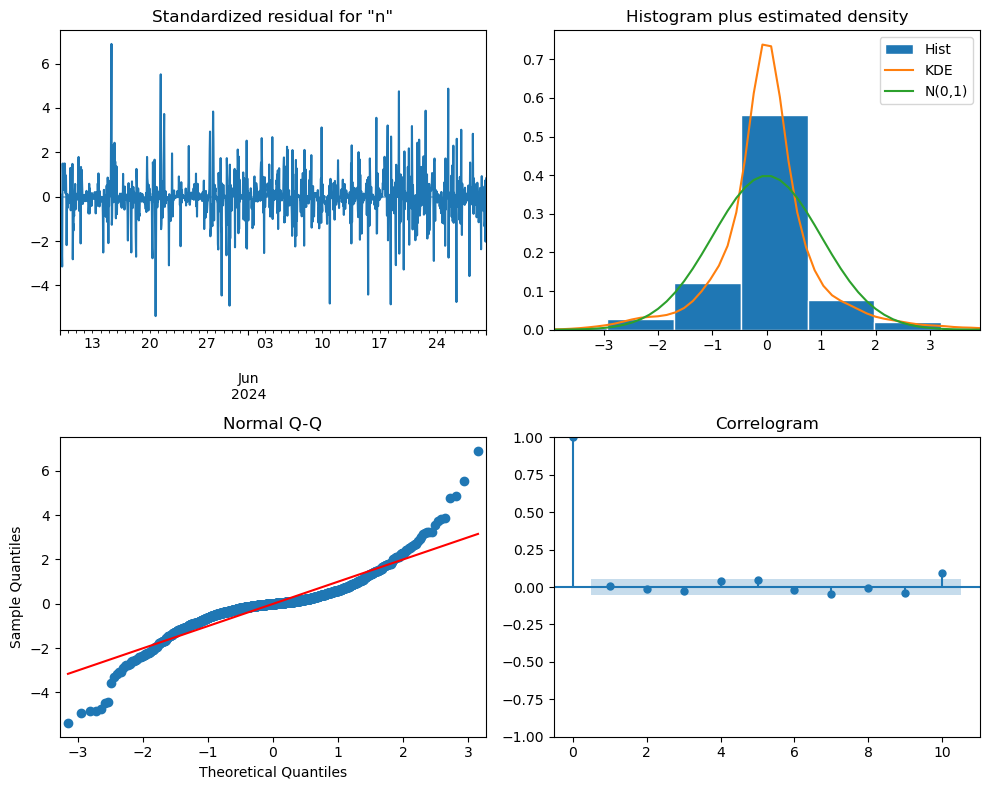

In [115]:
fig = res_final.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()

---

### Performance du modèle en prévision

In [116]:
n = len(Y)
T=int(0.8*n)
#séparation donnée entrainement et test
train = Y_model.iloc[:T]
test = Y_model.iloc[T:]

#modélisation des données d'entrainement
#modele_opt
model_train = sm.tsa.ARIMA(train, order=(p_opt, 0, q_opt)).fit()

#prédiction de la taille des données de test à comparer
pred = model_train.forecast(steps=len(test))

#comparaison avec les données de test
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 1262.1142836491636
RMSE : 2108.762799719802


- Le MAE signifie qu’en moyenne, l’erreur absolue de prévision est d’environ 1262 trajets par heure.
- Le RMSE est plus grand que le MAE, donc certaines erreurs sont nettement plus fortes que la moyenne

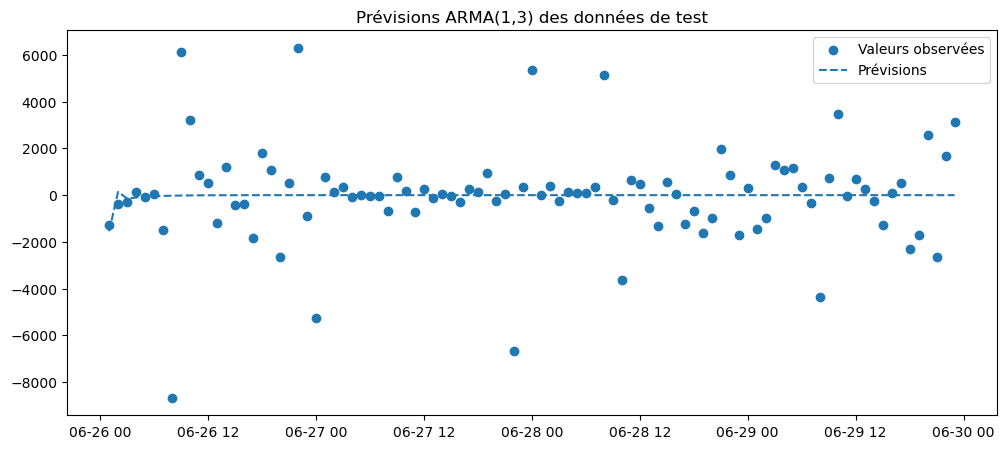

In [117]:
plt.figure(figsize=(12,5))
plt.scatter(test.index, test, label="Valeurs observées")
plt.plot(test.index, pred, label="Prévisions", linestyle="--")
plt.legend()
plt.title(f"Prévisions {modele_opt} des données de test")
plt.show()

# Même chose pour les autres variables du dataset

In [ ]:
Y_elec=data["proportion_velos_electriques"].dropna()
Y_duree=data["duree_moyenne_sec"].dropna()

In [ ]:
#résumons tout ce que nous avons fait dans une fonction

def etude_complete(Y):
    #aperçue de Yt
    plt.figure(figsize=(12, 5))
    plt.plot(Y)
    plt.title(f"Graphique A: Série temporelle {Y.name}")
    plt.xlabel("Heure de départ")
    plt.ylabel(f"{Y.name}")
    plt.grid(True)
    plt.show()

    # test d'une tendance polynomiale de degré 3
    t = np.arange(len(Y))
    X = sm.add_constant(np.column_stack([t, t**2,t**3]))
    mod = sm.OLS(Y.values, X).fit()

    # retrait de la tendance polynomiale de degrès k par différentiation
    # récupération du plus haut degré significatif k
    pvalues = mod.pvalues[1:]   # on enlève la constante
    degres_significatifs = [i+1 for i, p in enumerate(pvalues) if p < 0.05]

    if len(degres_significatifs) == 0:
        k = 0
        y_sans_tendance = Y.copy()
    else:
        k = max(degres_significatifs)
        y_sans_tendance = Y.copy()
        
        for i in range(k + 1):
            y_sans_tendance = y_sans_tendance.diff()

        y_sans_tendance = y_sans_tendance.dropna()

    # retrait de la saisonnalité supposée de periode 24 et 168
    Y_diff24 = y_sans_tendance.diff(24)
    Y_diff168= Y_diff24.diff(168)
    Y_model= Y_diff168.dropna()

    #vérifier stationnarité et ACF

    plt.figure(figsize=(12, 5))
    plt.plot(Y_model)

    fig, ax = plt.subplots(figsize=(18, 6))
    plot_acf(Y_model, lags=24*21,ax=ax)

    # graduations : tous les multiples de 24
    xticks = np.arange(0, 24*21 + 1, 24)
    ax.set_xticks(xticks)

    # forcer l'affichage avant de modifier les couleurs
    plt.draw()

    # couleur des labels
    for tick, val in zip(ax.get_xticklabels(), xticks):
        if val % 168 == 0 and val != 0:
            tick.set_color("green")
        elif val % 24 == 0 and val != 0:
            tick.set_color("red")
    plt.show()


    #Recherche du meilleur modèle ARMA par comparaison des AIC 

    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.filterwarnings("ignore")

    p = range(0, 5)
    q = range(0, 5)

    resultats = []

    for i, j in itertools.product(p, q):
        try:
            mod = sm.tsa.ARIMA(Y_model, order=(i, 0, j))
            res = mod.fit()

            if res.mle_retvals.get("converged", False):
                resultats.append({
                    "p": i,
                    "q": j,
                    "modele": f"ARMA({i},{j})",
                    "AIC": res.aic
                })

        except Exception:
            continue

    df_resultats = pd.DataFrame(resultats)
    df_resultats = df_resultats.sort_values("AIC").reset_index(drop=True)
    p_opt = int(df_resultats.loc[0, "p"])
    q_opt = int(df_resultats.loc[0, "q"])
    modele_opt = df_resultats.loc[0, "modele"]
    aic_opt = df_resultats.loc[0, "AIC"]

    print("Meilleur modèle retenu :", modele_opt)
    print("AIC =", aic_opt)

    res_final = sm.tsa.ARIMA(Y_model, order=(p_opt, 0, q_opt)).fit()
    print(res_final.summary())

    #performance du modèle en prévision

    n = len(Y)
    T=int(0.8*n)
    #séparation donnée entrainement et test
    train = Y_model.iloc[:T]
    test = Y_model.iloc[T:]

    #modélisation des données d'entrainement
    model_train = sm.tsa.ARIMA(train, order=(p_opt, 0, q_opt)).fit()

    #prédiction de la taille des données de test à comparer
    pred = model_train.forecast(steps=len(test))

    #comparaison avec les données de test
    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    print("MAE :", mae)
    print("RMSE :", rmse)

    plt.figure(figsize=(12,5))
    plt.scatter(test.index, test, label="Valeurs observées")
    plt.plot(test.index, pred, label="Prévisions", linestyle="--")
    plt.legend()
    plt.title(f"Prévisions {modele_opt} des données de test")
    plt.show()
    

In [ ]:
etude_complete(Y_duree)

In [ ]:
#etude_complete(Y_elec)